In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as wr
import random
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, r2_score
import xgboost as xgb
random.seed(42)
np.random.seed(42)
wr.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'C:\Users\User\Desktop\Sam\Data-kaggle download\Air Plane\Airline_Market_Fare_Prediction_Data\MarketFarePredictionData.csv')

In [3]:
df.head(5)

,MktCoupons,OriginCityMarketID,DestCityMarketID,OriginAirportID,DestAirportID,Carrier,NonStopMiles,RoundTrip,ODPairID,Pax,...,Circuity,Slot,Non_Stop,MktMilesFlown,OriginCityMarketID_freq,DestCityMarketID_freq,OriginAirportID_freq,DestAirportID_freq,Carrier_freq,ODPairID_freq
0,2,178,152,170,255,6,1807.0,1.0,4035,136.0,...,1.367460,0,0.0,1992.449761,0.004138,0.039783,0.004138,0.022049,0.116826,0.000132
1,2,178,152,170,194,20,1798.0,1.0,4035,136.0,...,1.051724,0,0.0,1992.449761,0.004138,0.039783,0.004138,0.008368,0.307651,0.000132
2,2,178,152,170,260,6,1784.0,0.0,4035,136.0,...,1.034753,0,0.0,1992.449761,0.004138,0.039783,0.004138,0.009366,0.116826,0.000132
3,2,178,152,170,255,6,1807.0,1.0,4035,136.0,...,1.029884,0,0.0,1992.449761,0.004138,0.039783,0.004138,0.022049,0.116826,0.000132
4,2,178,152,170,194,20,1798.0,1.0,4035,136.0,...,1.062291,0,0.0,1992.449761,0.004138,0.039783,0.004138,0.008368,0.307651,0.000132


In [4]:
df.tail(5)

,MktCoupons,OriginCityMarketID,DestCityMarketID,OriginAirportID,DestAirportID,Carrier,NonStopMiles,RoundTrip,ODPairID,Pax,...,Circuity,Slot,Non_Stop,MktMilesFlown,OriginCityMarketID_freq,DestCityMarketID_freq,OriginAirportID_freq,DestAirportID_freq,Carrier_freq,ODPairID_freq
1581273,1,92,266,167,286,7,532.0,0.0,2422,2519.0,...,1.000000,0,1.0,532.0,0.023245,0.001418,0.023245,0.001418,0.003414,3.161999e-06
1581274,1,92,266,167,286,7,532.0,1.0,2422,2519.0,...,1.000000,0,1.0,532.0,0.023245,0.001418,0.023245,0.001418,0.003414,3.161999e-06
1581275,2,247,12,256,74,15,976.0,1.0,5170,3312.0,...,1.186475,0,0.0,1158.0,0.000087,0.039433,0.000087,0.028036,0.056346,6.323999e-07
1581276,1,46,215,31,215,8,353.0,1.0,1283,2350.0,...,1.000000,0,1.0,353.0,0.017118,0.000324,0.017118,0.000324,0.015711,6.323999e-07
1581277,1,76,172,191,67,8,489.0,1.0,2041,2692.0,...,1.000000,0,1.0,489.0,0.001015,0.005788,0.001015,0.005788,0.015711,6.323999e-07


In [5]:
df.shape

(1581278, 26)

In [6]:
df.isnull().sum()

MktCoupons                 0
OriginCityMarketID         0
DestCityMarketID           0
OriginAirportID            0
DestAirportID              0
Carrier                    0
NonStopMiles               0
RoundTrip                  0
ODPairID                   0
Pax                        0
CarrierPax                 0
Average_Fare               0
Market_share               0
Market_HHI                 0
LCC_Comp                   0
Multi_Airport              0
Circuity                   0
Slot                       0
Non_Stop                   0
MktMilesFlown              0
OriginCityMarketID_freq    0
DestCityMarketID_freq      0
OriginAirportID_freq       0
DestAirportID_freq         0
Carrier_freq               0
ODPairID_freq              0
dtype: int64

In [7]:
df.columns

Index(['MktCoupons', 'OriginCityMarketID', 'DestCityMarketID',
       'OriginAirportID', 'DestAirportID', 'Carrier', 'NonStopMiles',
       'RoundTrip', 'ODPairID', 'Pax', 'CarrierPax', 'Average_Fare',
       'Market_share', 'Market_HHI', 'LCC_Comp', 'Multi_Airport', 'Circuity',
       'Slot', 'Non_Stop', 'MktMilesFlown', 'OriginCityMarketID_freq',
       'DestCityMarketID_freq', 'OriginAirportID_freq', 'DestAirportID_freq',
       'Carrier_freq', 'ODPairID_freq'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581278 entries, 0 to 1581277
Data columns (total 26 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   MktCoupons               1581278 non-null  int64  
 1   OriginCityMarketID       1581278 non-null  int64  
 2   DestCityMarketID         1581278 non-null  int64  
 3   OriginAirportID          1581278 non-null  int64  
 4   DestAirportID            1581278 non-null  int64  
 5   Carrier                  1581278 non-null  int64  
 6   NonStopMiles             1581278 non-null  float64
 7   RoundTrip                1581278 non-null  float64
 8   ODPairID                 1581278 non-null  int64  
 9   Pax                      1581278 non-null  float64
 10  CarrierPax               1581278 non-null  float64
 11  Average_Fare             1581278 non-null  float64
 12  Market_share             1581278 non-null  float64
 13  Market_HHI               1581278 non-null 

In [9]:
df.describe

<bound method NDFrame.describe of          MktCoupons  OriginCityMarketID  DestCityMarketID  OriginAirportID  \
0                 2                 178               152              170   
1                 2                 178               152              170   
2                 2                 178               152              170   
3                 2                 178               152              170   
4                 2                 178               152              170   
...             ...                 ...               ...              ...   
1581273           1                  92               266              167   
1581274           1                  92               266              167   
1581275           2                 247                12              256   
1581276           1                  46               215               31   
1581277           1                  76               172              191   

         DestAirportID  Carri

In [10]:
df.corr()

,MktCoupons,OriginCityMarketID,DestCityMarketID,OriginAirportID,DestAirportID,Carrier,NonStopMiles,RoundTrip,ODPairID,Pax,...,Circuity,Slot,Non_Stop,MktMilesFlown,OriginCityMarketID_freq,DestCityMarketID_freq,OriginAirportID_freq,DestAirportID_freq,Carrier_freq,ODPairID_freq
MktCoupons,1.000000,0.060176,0.064342,0.041985,0.043945,0.128699,0.235666,-0.065686,0.059141,-0.137663,...,0.518667,-0.062560,-0.994965,0.259700,-0.046597,-0.047732,-0.093488,-0.097734,0.313730,-0.049685
OriginCityMarketID,0.060176,1.000000,-0.064912,0.616457,-0.041622,-0.006810,0.078017,-0.006098,0.994804,-0.043110,...,0.027197,-0.016961,-0.061234,0.081603,-0.194019,0.092142,-0.348075,0.101220,-0.039069,0.000097
DestCityMarketID,0.064342,-0.064912,1.000000,-0.040649,0.617566,-0.004993,0.079640,-0.008631,-0.049342,-0.037335,...,0.026978,-0.015529,-0.065354,0.083411,0.092108,-0.194473,0.100821,-0.354835,-0.035716,0.003335
OriginAirportID,0.041985,0.616457,-0.040649,1.000000,-0.037300,0.015842,0.074656,-0.001598,0.616796,-0.017597,...,0.016961,-0.037603,-0.043330,0.077142,-0.093662,0.038051,-0.109424,0.026974,0.015871,-0.004568
DestAirportID,0.043945,-0.041622,0.617566,-0.037300,1.000000,0.017183,0.077248,-0.002332,-0.031051,-0.015941,...,0.013730,-0.035908,-0.045106,0.079313,0.038856,-0.091786,0.028345,-0.110720,0.017833,-0.001987
Carrier,0.128699,-0.006810,-0.004993,0.015842,0.017183,1.000000,-0.164421,0.061025,-0.006183,-0.090373,...,0.079324,-0.130046,-0.132377,-0.154774,-0.052271,-0.057235,-0.118194,-0.124398,0.445564,-0.111009
NonStopMiles,0.235666,0.078017,0.079640,0.074656,0.077248,-0.164421,1.000000,-0.035753,0.079383,-0.038803,...,-0.009104,0.016567,-0.234652,0.998268,0.149273,0.145617,0.141831,0.137328,-0.003954,0.229655
RoundTrip,-0.065686,-0.006098,-0.008631,-0.001598,-0.002332,0.061025,-0.035753,1.000000,-0.007893,-0.052790,...,-0.054286,-0.057062,0.067310,-0.036563,-0.044409,-0.046899,-0.024387,-0.022930,0.053270,-0.064824
ODPairID,0.059141,0.994804,-0.049342,0.616796,-0.031051,-0.006183,0.079383,-0.007893,1.000000,-0.039719,...,0.026871,0.000403,-0.060210,0.082911,-0.179145,0.088697,-0.349877,0.099428,-0.047498,0.010503
Pax,-0.137663,-0.043110,-0.037335,-0.017597,-0.015941,-0.090373,-0.038803,-0.052790,-0.039719,1.000000,...,-0.061556,0.260073,0.140973,-0.048107,0.460185,0.457577,0.255492,0.252585,0.009708,0.842939


In [11]:
df = df.drop(columns=['OriginCityMarketID','DestCityMarketID','OriginAirportID','DestAirportID','ODPairID'], axis=1)

<Axes: >

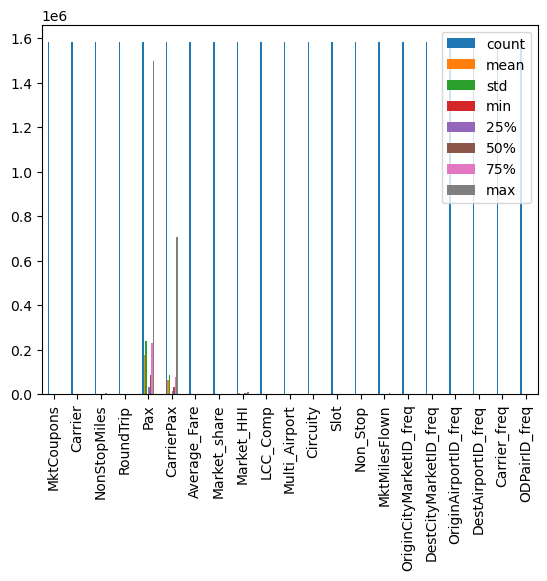

In [12]:
df.describe().T.plot(kind='bar')

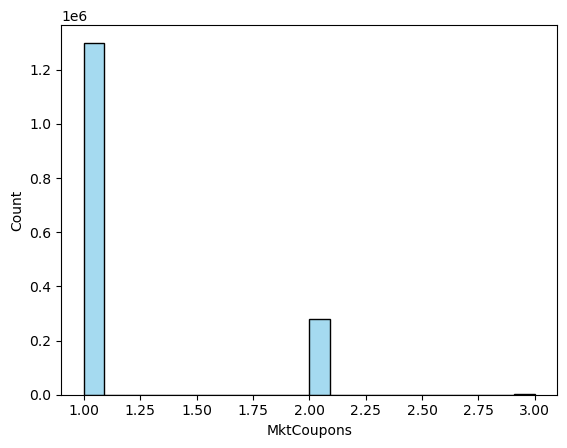

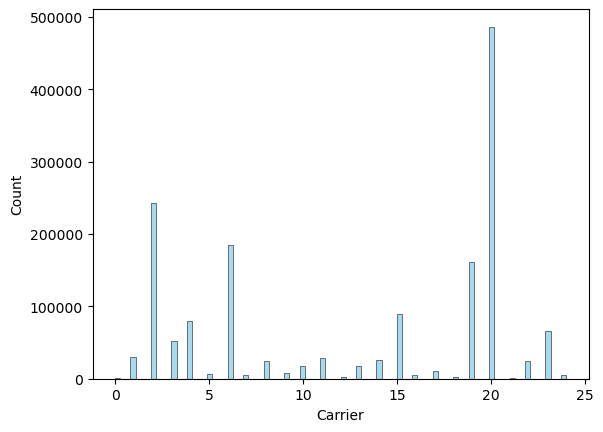

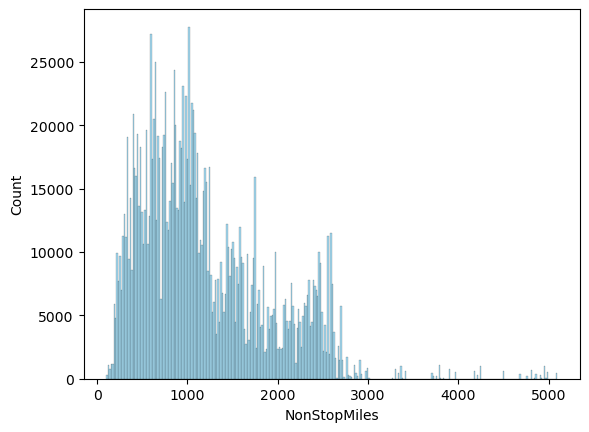

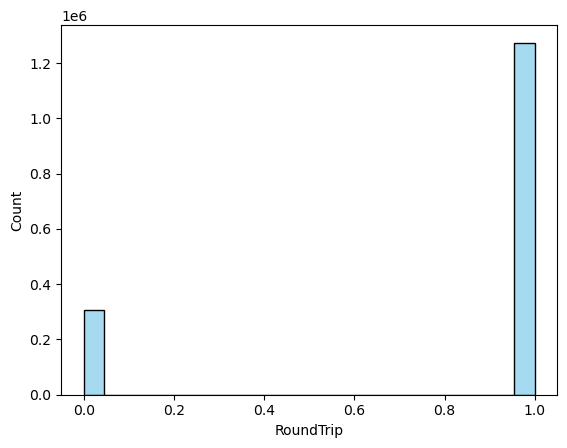

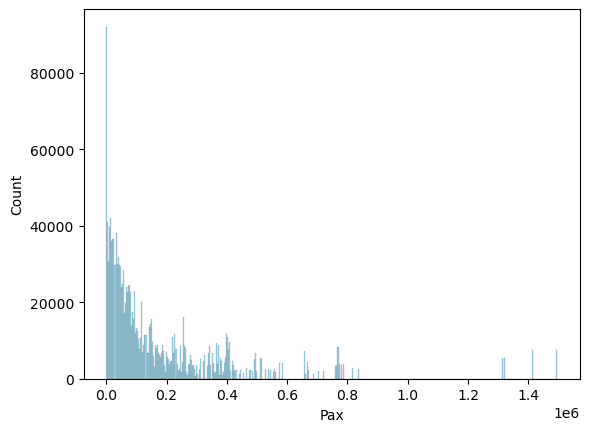

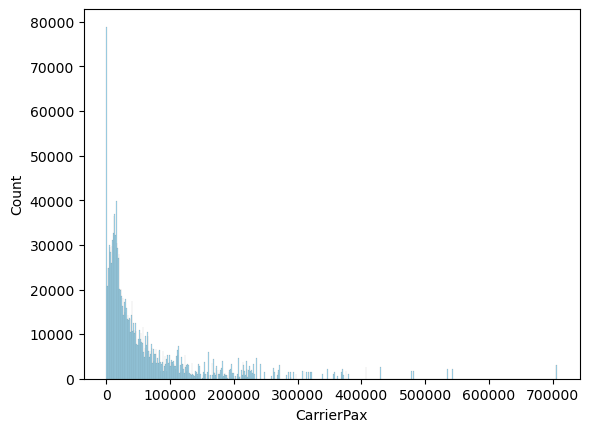

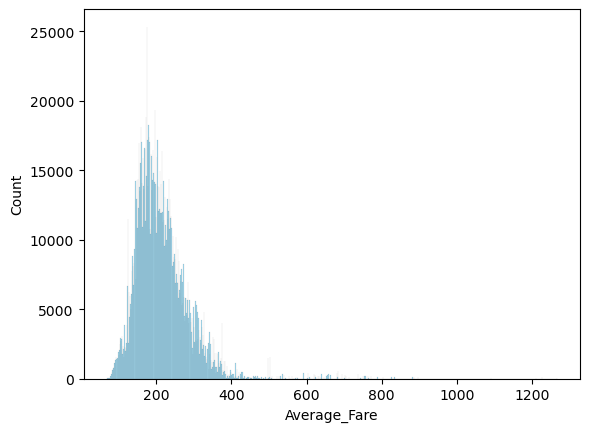

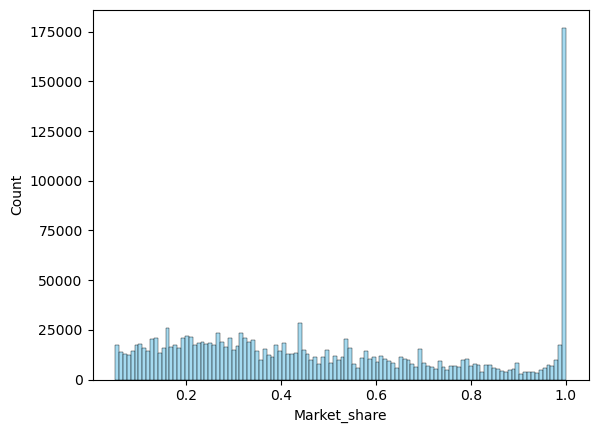

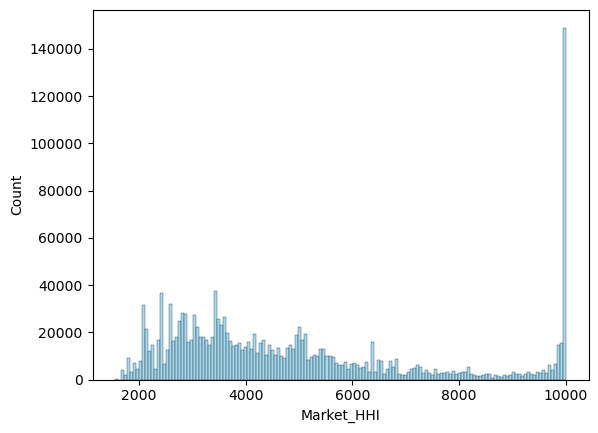

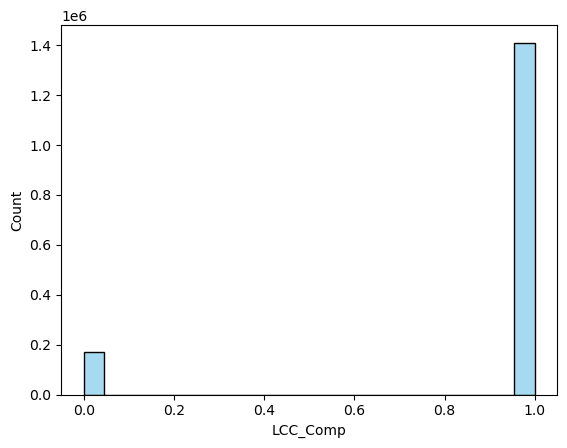

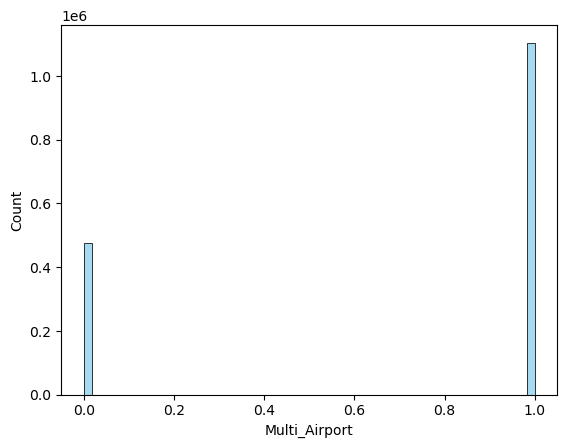

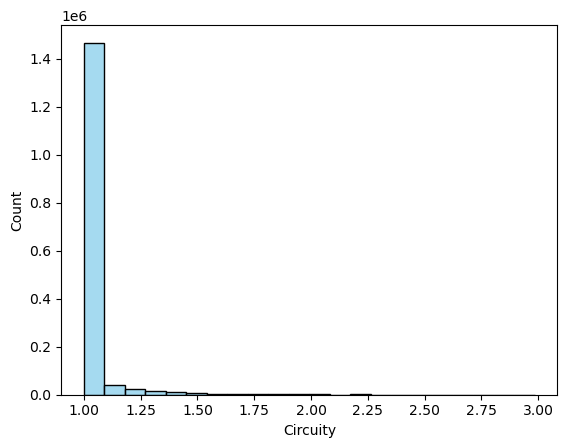

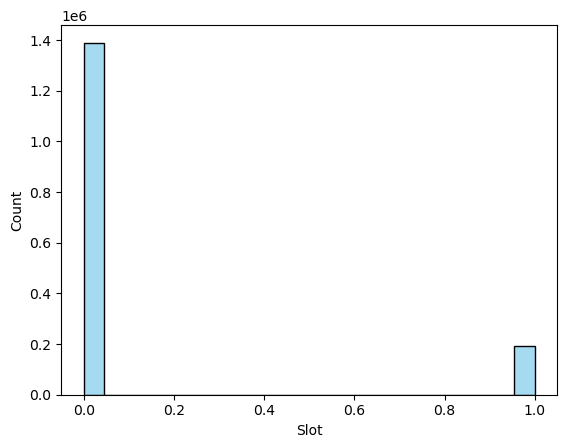

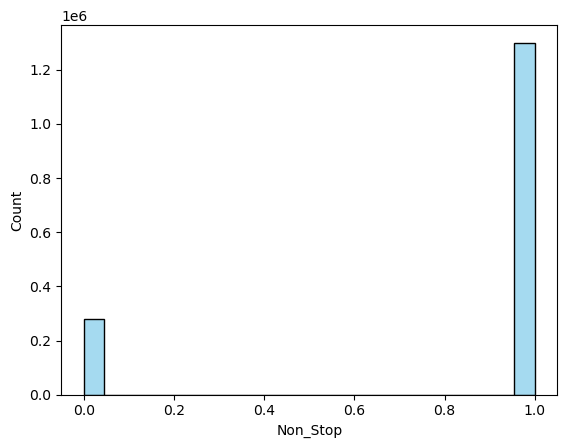

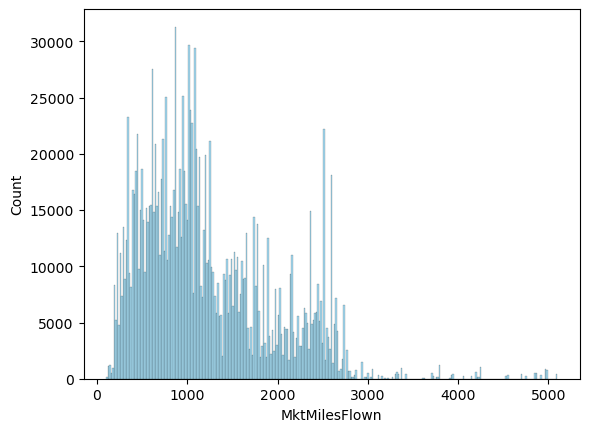

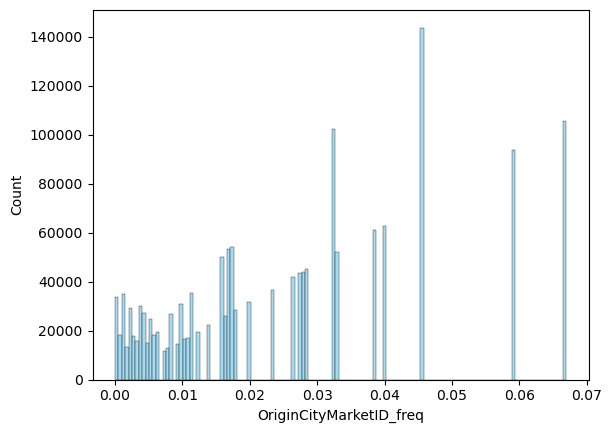

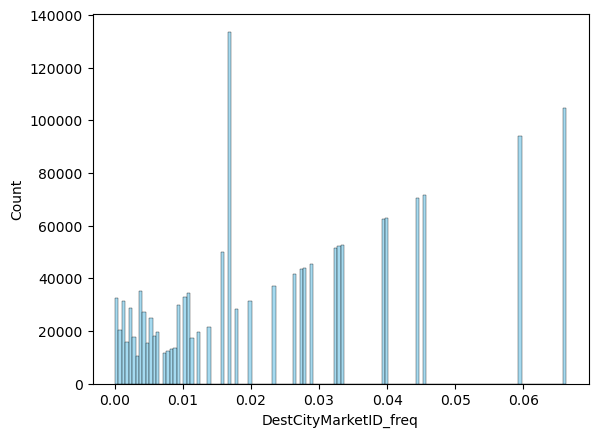

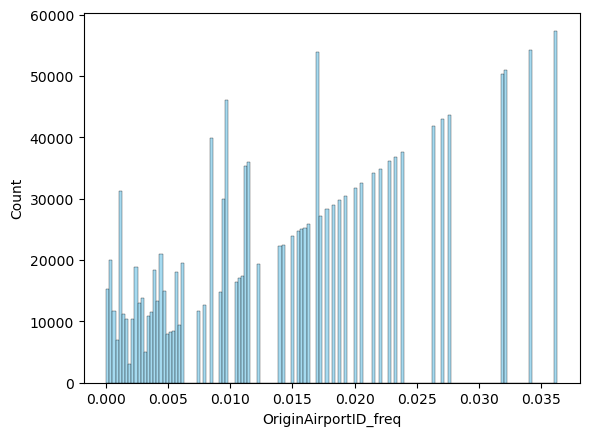

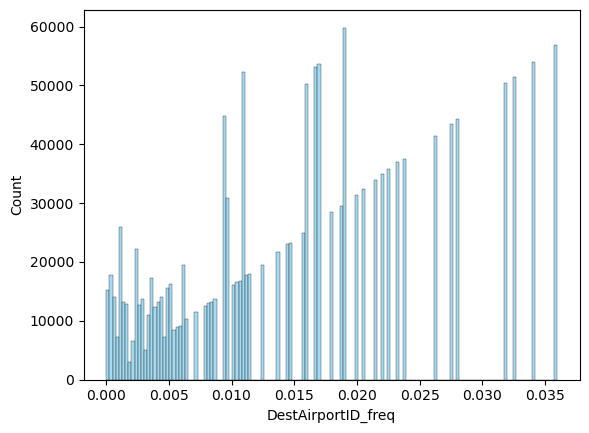

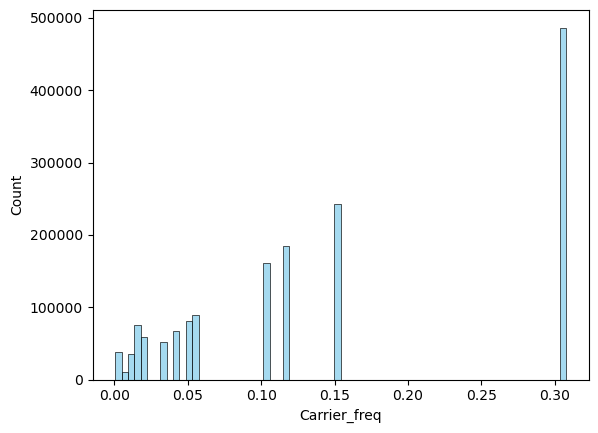

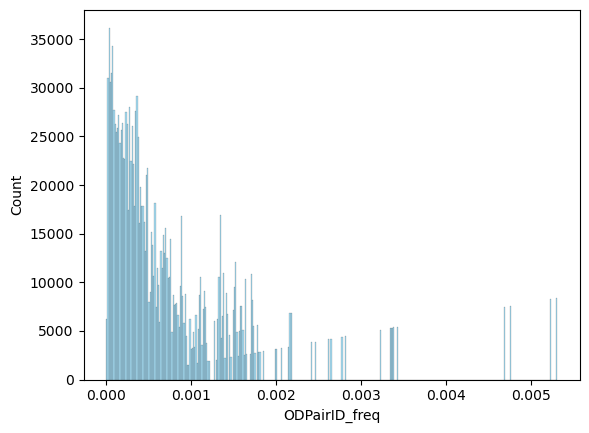

In [13]:
numaric_col= df.select_dtypes(['number']).columns
for col in numaric_col:
    sns.histplot(data = df, x = col, color='skyblue')
    plt.show()

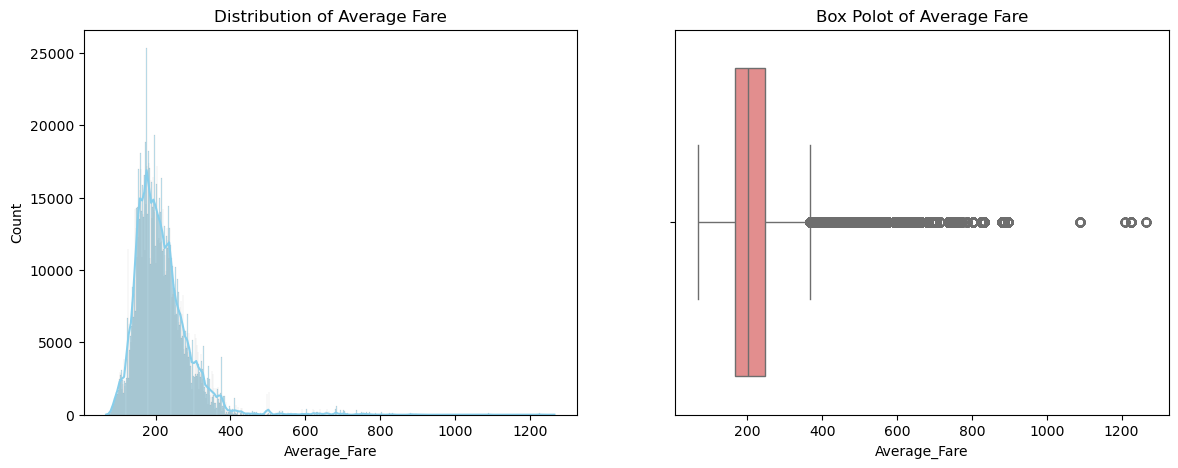

In [14]:
fig, axs = plt.subplots(1,2, figsize=(14,5))
sns.histplot( x = df['Average_Fare'],  kde = True, color = 'skyblue', ax = axs[0])
axs[0].set_title('Distribution of Average Fare')
sns.boxplot( x = df['Average_Fare'], ax = axs[1], color ='lightcoral')
axs[1].set_title('Box Polot of Average Fare')
plt.show()

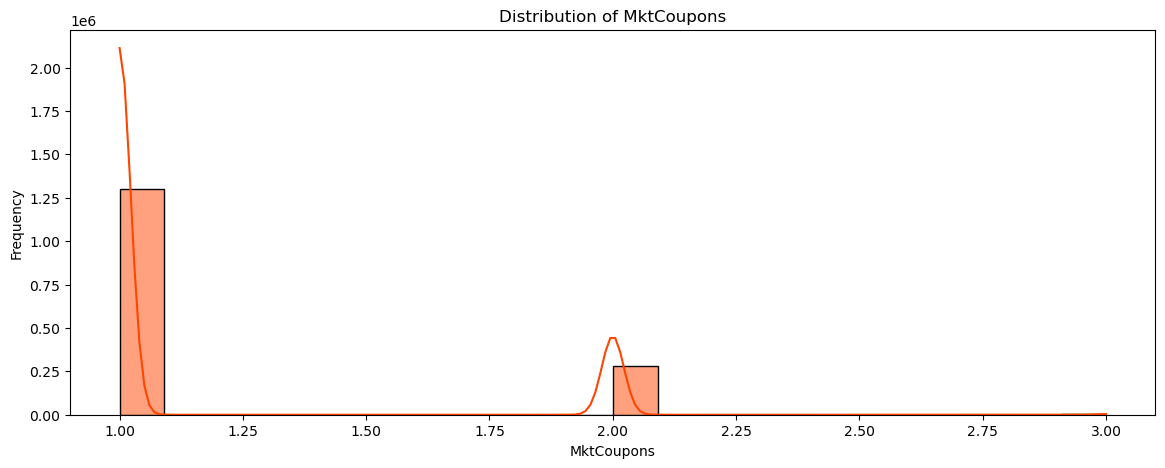

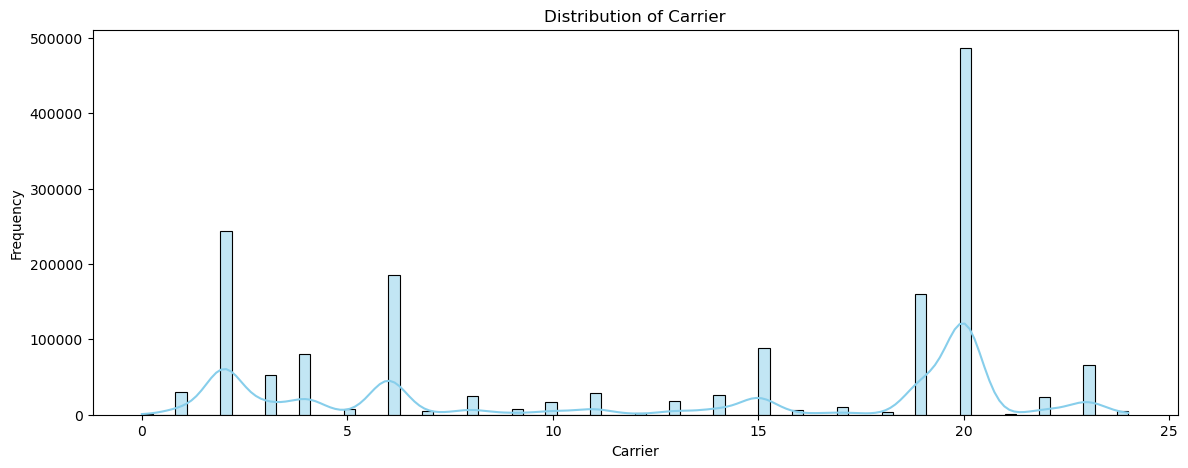

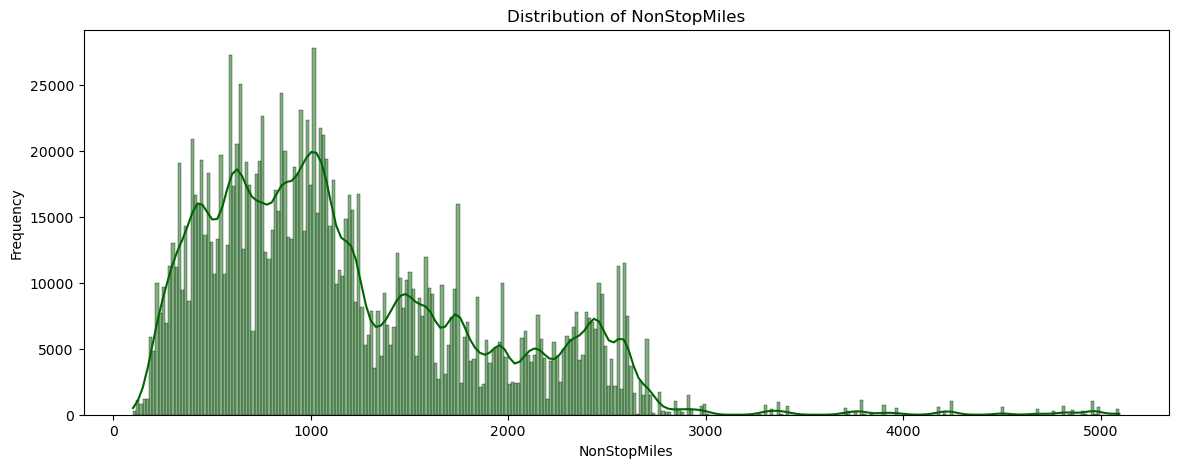

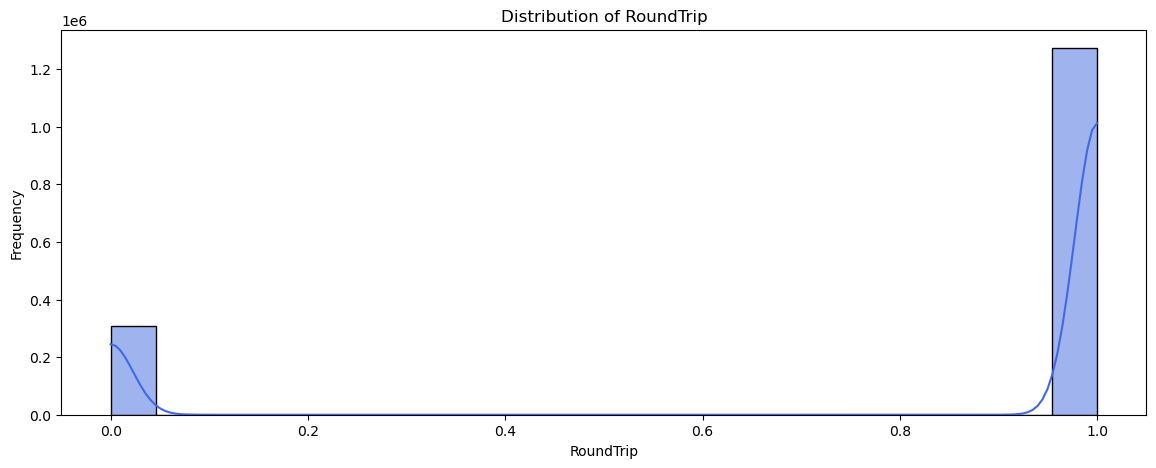

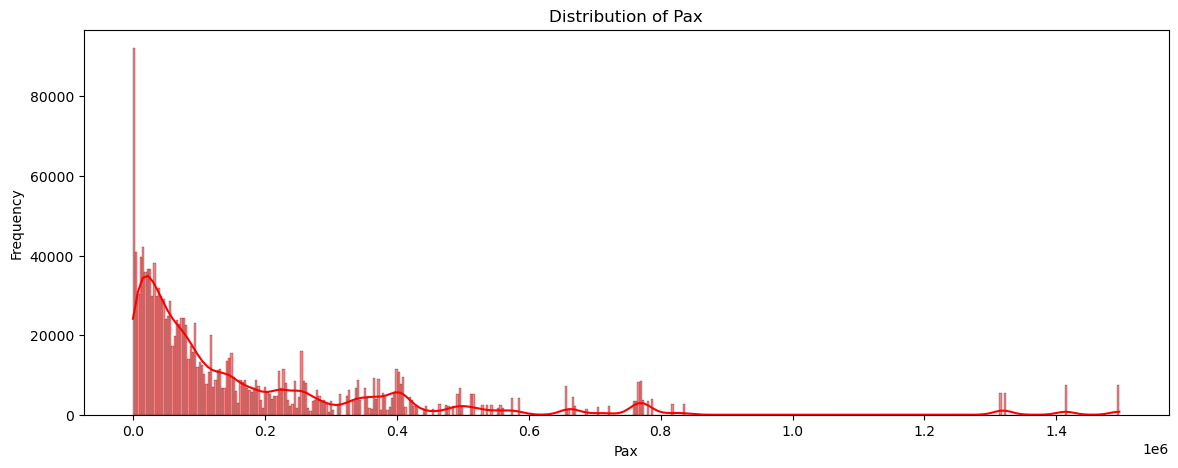

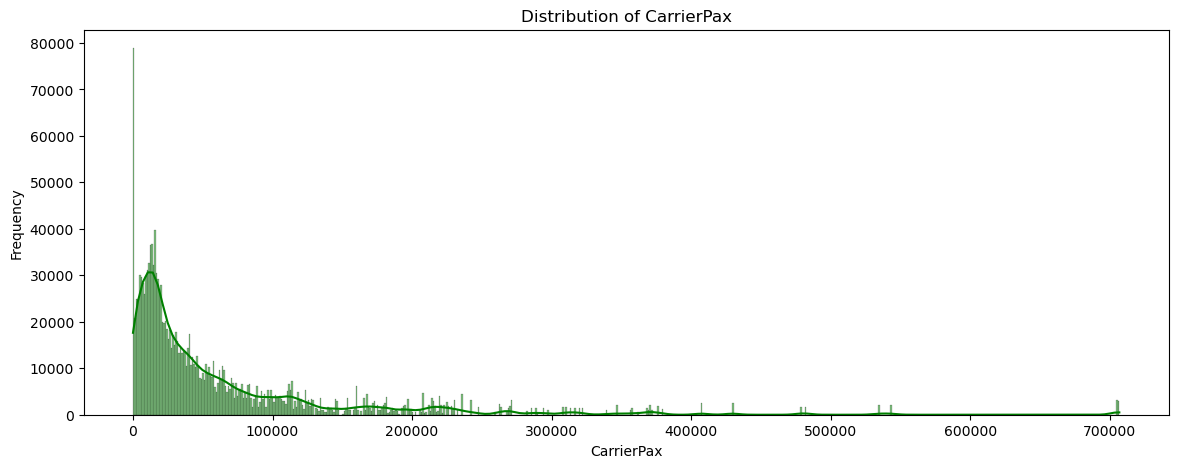

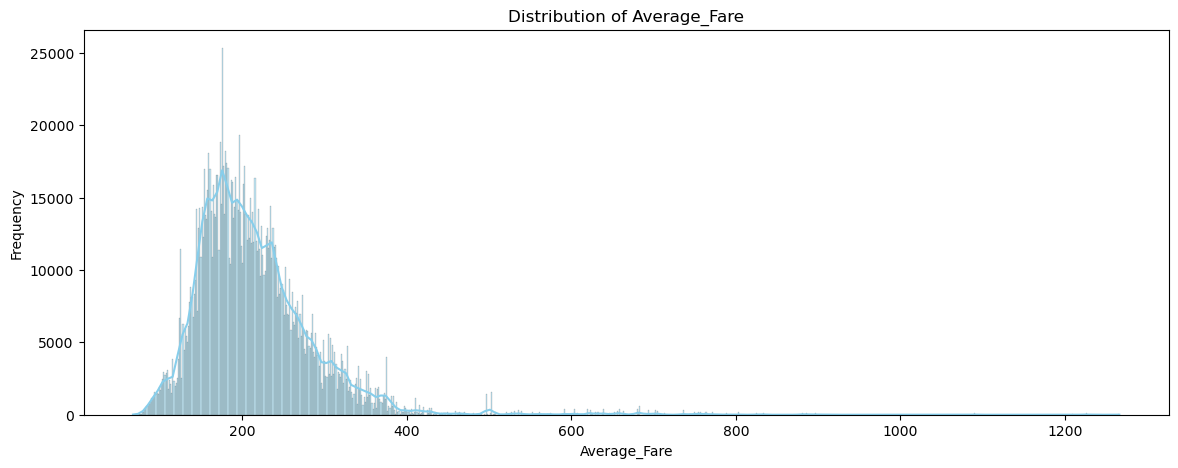

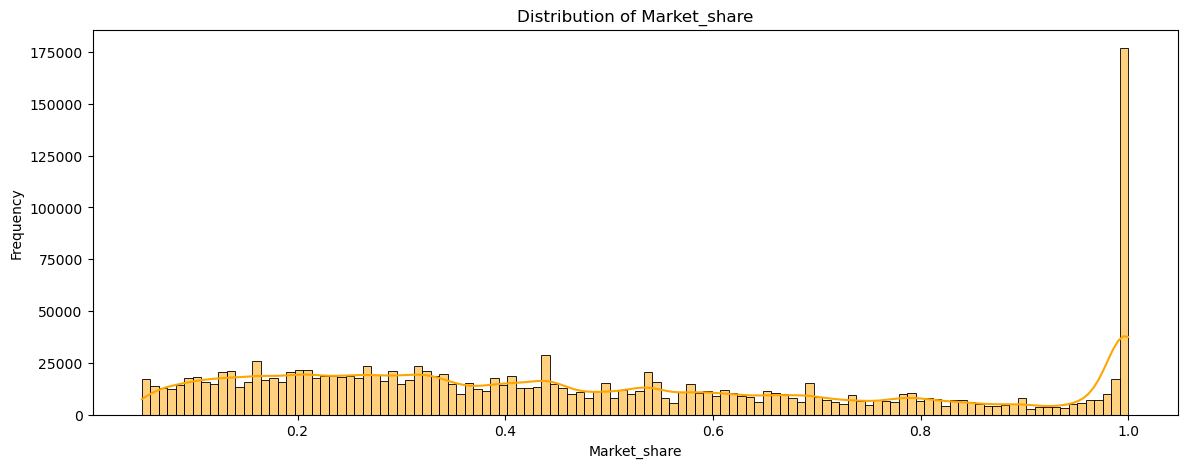

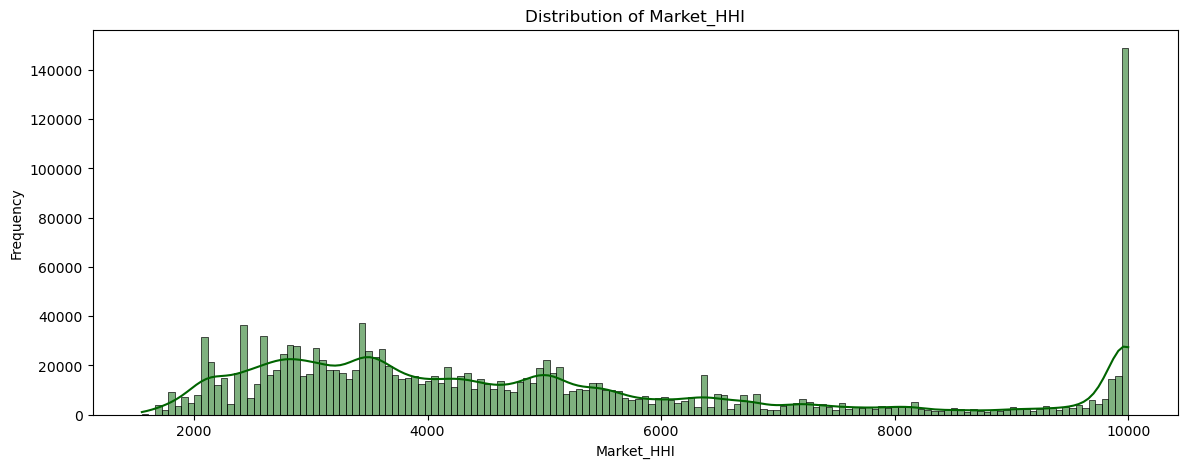

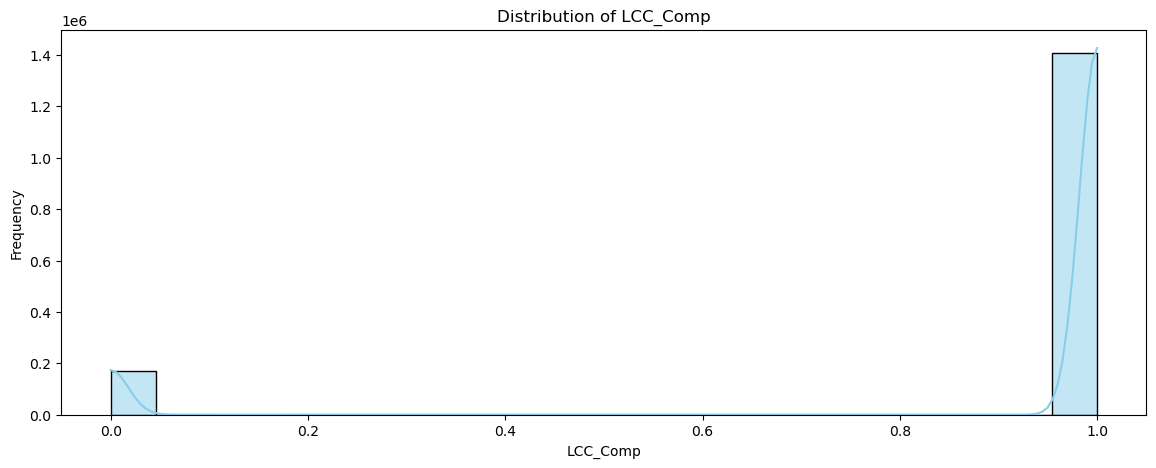

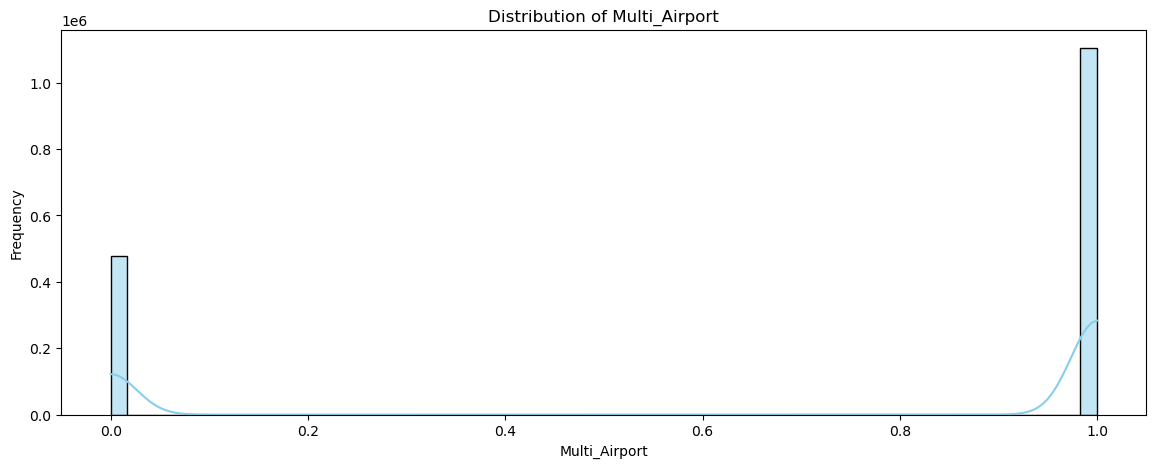

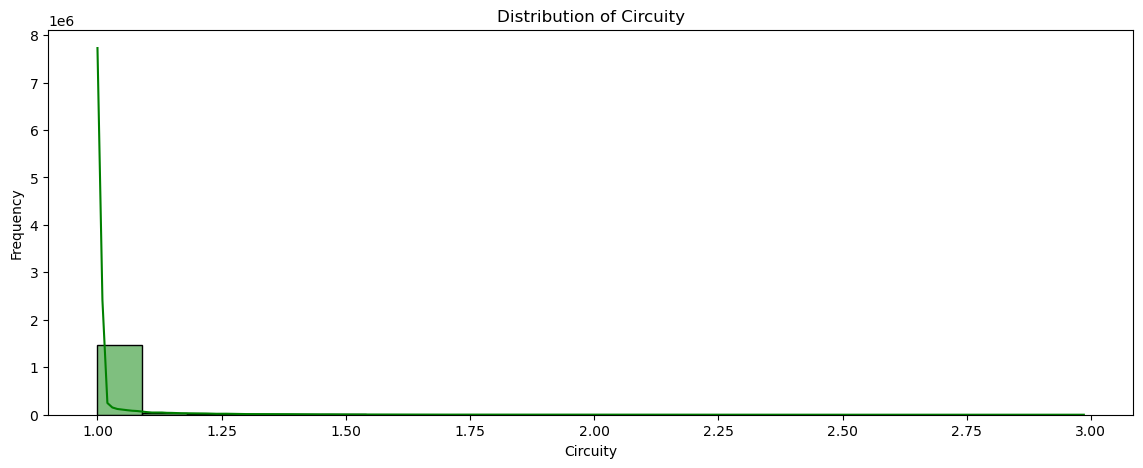

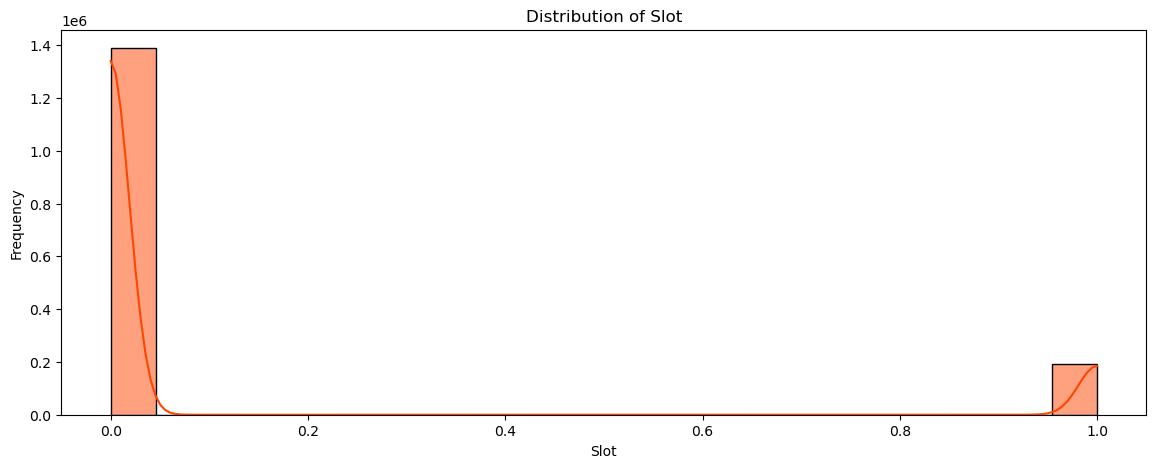

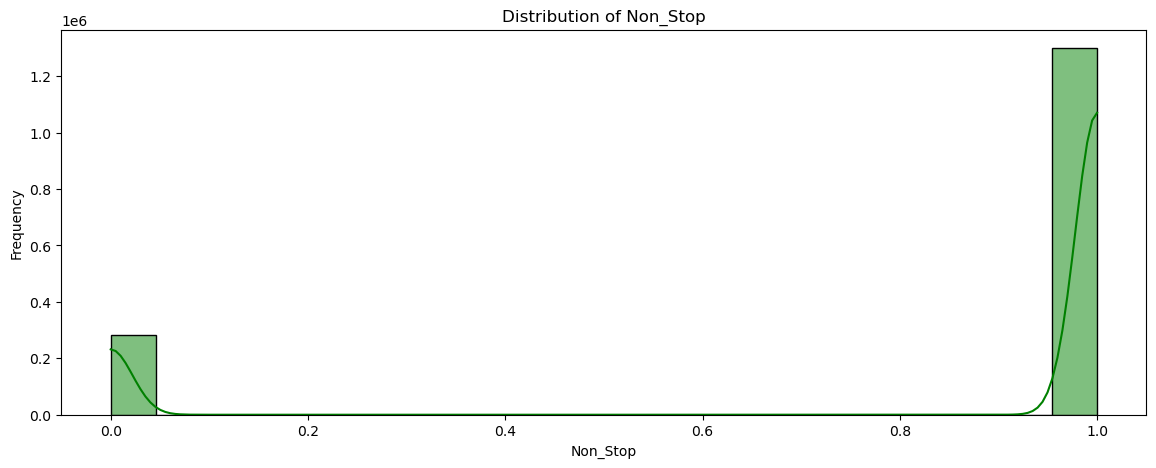

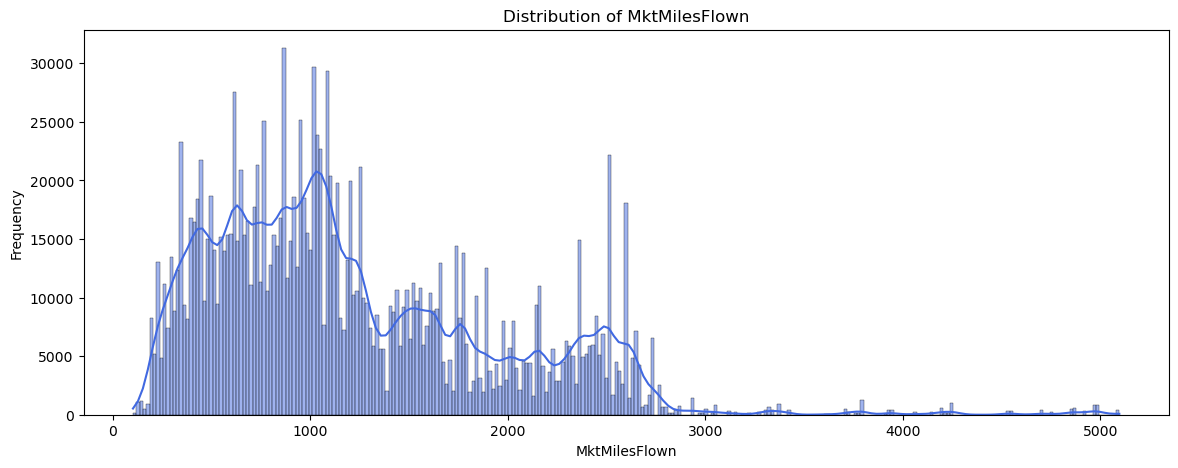

In [15]:
#Distribution of MktCoupons
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['MktCoupons'], color= 'orangered', kde= True)
plt.xlabel('MktCoupons')
plt.ylabel('Frequency')
plt.title('Distribution of MktCoupons')
plt.show()
print('\n')
#Distribution of Carrier
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['Carrier'], color= 'skyblue', kde= True)
plt.xlabel('Carrier')
plt.ylabel('Frequency')
plt.title('Distribution of Carrier')
plt.show()
print('\n')
#Distribution of NonStopMiles
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['NonStopMiles'], color= 'darkgreen', kde= True)
plt.xlabel('NonStopMiles')
plt.ylabel('Frequency')
plt.title('Distribution of NonStopMiles')
plt.show()
print('\n')
#Distribution of  RoundTrip
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['RoundTrip'], color= 'royalblue', kde= True)
plt.xlabel('RoundTrip')
plt.ylabel('Frequency')
plt.title('Distribution of RoundTrip')
plt.show()
print('\n')
#Distribution of Pax
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['Pax'], color= 'red', kde= True)
plt.xlabel('Pax')
plt.ylabel('Frequency')
plt.title('Distribution of Pax')
plt.show()
print('\n')
#Distribution of CarrierPax
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['CarrierPax'], color= 'green', kde= True)
plt.xlabel('CarrierPax')
plt.ylabel('Frequency')
plt.title('Distribution of CarrierPax')
plt.show()
#Distribution of Average_Fare
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['Average_Fare'], color= 'skyblue', kde= True)
plt.xlabel('Average_Fare')
plt.ylabel('Frequency')
plt.title('Distribution of Average_Fare')
plt.show()
#Distribution of Market_share
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['Market_share'], color= 'orange', kde= True)
plt.xlabel('Market_share')
plt.ylabel('Frequency')
plt.title('Distribution of Market_share')
plt.show()
#Distribution of Market_HHI
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['Market_HHI'], color= 'darkgreen', kde= True)
plt.xlabel('Market_HHI')
plt.ylabel('Frequency')
plt.title('Distribution of Market_HHI')
plt.show()
#Distribution of LCC_Comp
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['LCC_Comp'], color= 'skyblue', kde= True)
plt.xlabel('LCC_Comp')
plt.ylabel('Frequency')
plt.title('Distribution of LCC_Comp')
plt.show()
#Distribution of Multi_Airport
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['Multi_Airport'], color= 'skyblue', kde= True)
plt.xlabel('Multi_Airport')
plt.ylabel('Frequency')
plt.title('Distribution of Multi_Airport')
plt.show()
#Distribution of Circuity
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['Circuity'], color= 'green', kde= True)
plt.xlabel('Circuity')
plt.ylabel('Frequency')
plt.title('Distribution of Circuity')
plt.show()
#Distribution of Slot
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['Slot'], color= 'orangered', kde= True)
plt.xlabel('Slot')
plt.ylabel('Frequency')
plt.title('Distribution of Slot')
plt.show()
#Distribution of Non_Stop
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['Non_Stop'], color= 'green', kde= True)
plt.xlabel('Non_Stop')
plt.ylabel('Frequency')
plt.title('Distribution of Non_Stop')
plt.show()
#Distribution of MktMilesFlown
plt.figure(figsize= (14,5))
sns.histplot(data= df, x = df['MktMilesFlown'], color= 'royalblue', kde= True)
plt.xlabel('MktMilesFlown')
plt.ylabel('Frequency')
plt.title('Distribution of MktMilesFlown')
plt.show()

In [16]:
df.columns

Index(['MktCoupons', 'Carrier', 'NonStopMiles', 'RoundTrip', 'Pax',
       'CarrierPax', 'Average_Fare', 'Market_share', 'Market_HHI', 'LCC_Comp',
       'Multi_Airport', 'Circuity', 'Slot', 'Non_Stop', 'MktMilesFlown',
       'OriginCityMarketID_freq', 'DestCityMarketID_freq',
       'OriginAirportID_freq', 'DestAirportID_freq', 'Carrier_freq',
       'ODPairID_freq'],
      dtype='object')

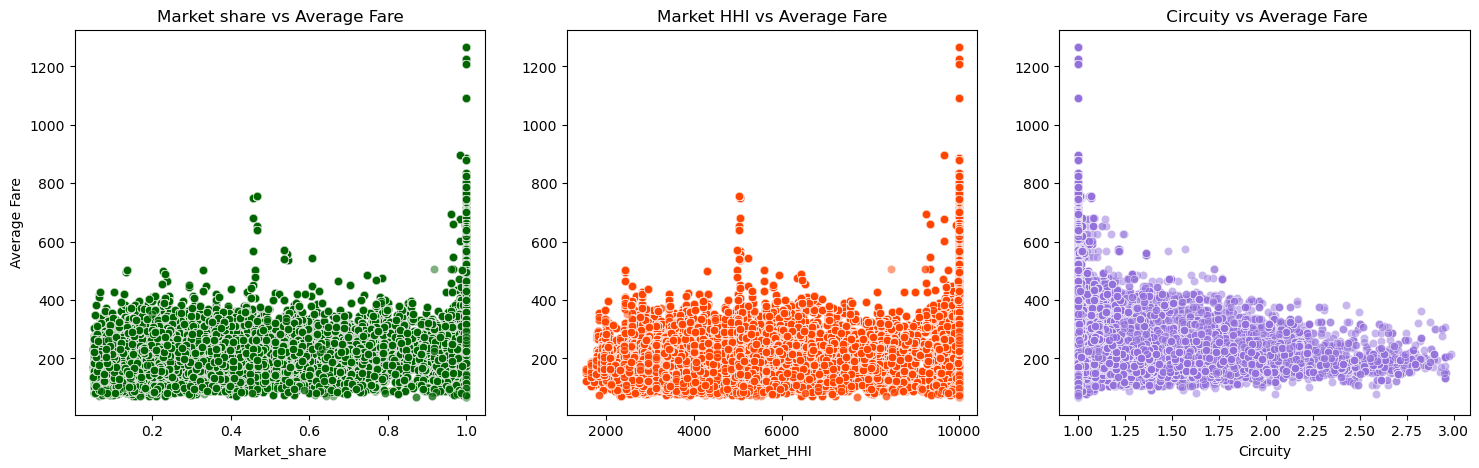

In [17]:
fig, axs = plt.subplots(1,3, figsize=(18,5))
# Market share vs Average Fare
sns.scatterplot(x = 'Market_share', y = 'Average_Fare', data = df, alpha = 0.5, color = 'darkgreen', ax= axs[0])
axs[0].set_title('Market share vs Average Fare')
axs[0].set_xlabel('Market_share')
axs[0].set_ylabel('Average Fare')

# Market HHI vs Average Fare
sns.scatterplot(x = 'Market_HHI', y = 'Average_Fare', data = df, alpha = 0.5, color = 'orangered', ax= axs[1])
axs[1].set_title('Market HHI vs Average Fare')
axs[1].set_xlabel('Market_HHI')
axs[1].set_ylabel('')


# Circuity  vs Average Fare
sns.scatterplot(x = 'Circuity', y = 'Average_Fare', data = df, alpha = 0.5, color = 'mediumpurple', ax= axs[2])
axs[2].set_title(' Circuity vs Average Fare')
axs[2].set_xlabel('Circuity')
axs[2].set_ylabel('')

plt.show()

In [18]:
X = df.drop(columns=['Average_Fare'], axis=1)
y = df['Average_Fare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [19]:
rfr = RandomForestRegressor(n_estimators= 200, n_jobs = -1)

In [20]:
model = rfr.fit(X_train, y_train)

In [21]:
y_pred = model.predict(X_test)

In [22]:
score = r2_score(y_test, y_pred)

In [23]:
print(type(y_test), y_test[:5])
print(type(y_pred), y_pred[:5])

<class 'pandas.core.series.Series'> 115482     207.44
1346404    266.08
1166331    197.02
540157     138.88
245966     306.59
Name: Average_Fare, dtype: float64
<class 'numpy.ndarray'> [207.44 266.08 197.02 138.88 306.59]


In [24]:
print(score)

0.9999535578326816
